# From CSV to Parquet with Pandas, Polars, and PySpark

This is a **data engineering** walkthrough, not a data analysis assignment — you will pick your own dataset for the homework later. Your job here is to run each cell in order and watch three things change as the data grows: file size, read time, and runtime.

**What you will do**

1. Open a 100-row CSV and see what the format really is.
2. Grow it to a million rows and measure where CSV breaks down.
3. Switch to Parquet and measure the difference.
4. Clean a dataset in three lines: deduplicate, impute, normalize.
5. Write the *same* query in Pandas, Polars (eager and lazy), and PySpark.
6. Compare their runtimes from 100 rows up to one billion.

## Before you start

Install the *Python* and *Jupyter* extensions.

Then run these two commands in the project folder:

```bash
make setup   # creates .venv and registers the "Dataframe Engines" Jupyter kernel
make data    # downloads MovieLens 32M and writes the Parquet files used below
```

Finally, pick the **Dataframe Engines** kernel in the top-right of this notebook. PySpark also needs **Java 17** — if it is missing, the Spark cells say so and skip themselves rather than crash.

In [1]:
# Load the libraries we will use. A library is a bundle of ready-made tools.
# pandas / polars / pyspark = three ways to work with tables of data
# matplotlib / seaborn     = drawing charts
import os, platform, shutil, subprocess, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import FuncFormatter, NullFormatter

warnings.filterwarnings("ignore", message=".*pandas >= 3.0.0.*")
sns.set_theme(style="whitegrid", context="notebook")

# Chart helpers: print "10 ms" instead of 0.01, and "1 s" instead of 1.0
SECONDS = FuncFormatter(lambda v, _: f"{v * 1000:g} ms" if v < 1 else f"{v:g} s")
PLAIN = FuncFormatter(lambda v, _: f"{v:g}")


def log_y(axis, ticks, formatter=SECONDS):
    """Readable log ticks such as '10 ms' instead of matplotlib's 10^-2."""
    axis.set_yscale("log")
    axis.set_yticks(ticks)
    axis.yaxis.set_major_formatter(formatter)
    axis.yaxis.set_minor_formatter(NullFormatter())


ENGINES = ["Pandas", "Polars Eager", "Polars Lazy", "PySpark"]
COLORS = dict(zip(ENGINES, sns.color_palette("colorblind", 4)))

# Find the project folder whether you opened Jupyter from the root or from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_DIR = ROOT / "data/parquet"
SYNTHETIC_DIR = ROOT / "data/synthetic"
FORMAT_DIR = ROOT / "data/formats"
MOVIES_PATH = PARQUET_DIR / "movies.parquet"
RATINGS_PATH = PARQUET_DIR / "ratings_1m.parquet"
assert MOVIES_PATH.exists() and RATINGS_PATH.exists(), "Run `make data` first."

MIN_RATINGS = 1_000  # a movie is "widely rated" if at least this many people rated it
TOP_N = 10  # how many movies to show in the top tables

# Point local PySpark at a Homebrew OpenJDK 17 install if JAVA_HOME is unset.
for candidate in [
    Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
    Path("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
]:
    if "JAVA_HOME" not in os.environ and candidate.exists():
        os.environ["JAVA_HOME"] = str(candidate)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
JAVA_READY = bool(os.environ.get("JAVA_HOME") or shutil.which("java"))


def describe_machine():
    """Runtimes are only meaningful next to the machine that produced them."""
    cpu = platform.machine()
    if platform.system() == "Darwin":
        cpu = (
            subprocess.run(
                ["sysctl", "-n", "machdep.cpu.brand_string"],
                capture_output=True,
                text=True,
            ).stdout.strip()
            or cpu
        )
    try:
        import psutil

        memory = f"{psutil.virtual_memory().total / 1024**3:.0f} GB RAM"
    except ImportError:
        memory = "unknown RAM"
    return (
        f"{cpu}, {os.cpu_count()} cores, {memory}, "
        f"{platform.system()} {platform.release()}, Python {platform.python_version()}"
    )


MACHINE = describe_machine()
java_note = "ready" if JAVA_READY else "missing, Spark cells will be skipped"
print(MACHINE)
print(f"pandas {pd.__version__} | polars {pl.__version__} | Java {java_note}")

Apple M4 Pro, 12 cores, 24 GB RAM, Darwin 24.3.0, Python 3.14.3
pandas 3.0.5 | polars 1.44.1 | Java ready


## 1. Start small: 100 rows in a CSV

CSV is how most datasets will arrive on your desk. It is plain text — one line per row, values separated by commas — and at this size that is a perfectly good thing to be. You could open the file in any editor and read it yourself.

Run the cell below. It writes 100 rows to a CSV, prints the header line exactly as stored on disk, and reads it back. Each row is one rating event: one user rated one movie at one moment.

In [2]:
# Make a folder for the small CSV/Parquet files this notebook writes.
FORMAT_DIR.mkdir(parents=True, exist_ok=True)

# We only need four columns. A column is one field, like "rating".
COLUMNS = ["userId", "movieId", "rating", "timestamp"]
source = pd.read_parquet(RATINGS_PATH, columns=COLUMNS)  # load the 1M-row table

# Take the first 100 rows and save them as a CSV (plain text, comma-separated).
tiny_csv = FORMAT_DIR / "ratings_100.csv"
source.head(100).to_csv(tiny_csv, index=False)

print(f"{tiny_csv.name}: {tiny_csv.stat().st_size:,} bytes")
print(tiny_csv.read_text().splitlines()[0])  # the header line, as stored on disk
display(pd.read_csv(tiny_csv).head())  # first 5 rows, as a table

ratings_100.csv: 2,662 bytes
userId,movieId,rating,timestamp


,userId,movieId,rating,timestamp
0,163692,201749,4.0,1601327701
1,63885,914,3.0,851349682
2,197767,593,3.5,1546504318
3,140531,1291,4.0,942034779
4,159429,265148,2.5,1657473296


## 2. Scale to 100,000 rows: where CSV starts to hurt

Now grow the same file. Nothing changes except its length, but four costs show up at once — and the cell below measures each of them against Parquet at three sizes:

- **Size.** Every number is stored as text, so `4.5` takes three characters.
- **Parse time.** Reading means scanning the file character by character and converting every field.
- **No schema.** The file stores no types, so the reader has to *guess* them from the contents.
- **No column skipping.** Even if you need 2 of 4 columns, the reader still walks every line.

In [3]:
# Three sizes to compare. Underscores are just visual: 100_000 == 100000.
SIZES = [100, 100_000, 1_000_000]
LABELS = {100: "100", 100_000: "100k", 1_000_000: "1m"}


def timed(read_fn):
    """Run a function and return (seconds it took, the result)."""
    start = time.perf_counter()
    frame = read_fn()
    return time.perf_counter() - start, frame


records = []
for rows in SIZES:
    sample = source.head(rows)  # first N rows of the same table
    csv_path = FORMAT_DIR / f"ratings_{LABELS[rows]}.csv"
    parquet_path = FORMAT_DIR / f"ratings_{LABELS[rows]}.parquet"
    sample.to_csv(csv_path, index=False)  # write as CSV
    sample.to_parquet(parquet_path, index=False)  # write the SAME rows as Parquet

    # Time three reads: whole CSV, whole Parquet, and Parquet with only 2 of 4 columns.
    csv_seconds, _ = timed(lambda: pd.read_csv(csv_path))
    parquet_seconds, _ = timed(lambda: pd.read_parquet(parquet_path))
    subset_seconds, _ = timed(
        lambda: pd.read_parquet(parquet_path, columns=["movieId", "rating"])
    )
    records.append(
        {
            "rows": rows,
            "csv_mb": csv_path.stat().st_size / 1e6,  # file size in megabytes
            "parquet_mb": parquet_path.stat().st_size / 1e6,
            "csv_read_s": csv_seconds,
            "parquet_read_s": parquet_seconds,
            "parquet_2col_s": subset_seconds,
        }
    )

formats = pd.DataFrame(records)
# How many times smaller / faster is Parquet? e.g. "2.3x"
formats["size_win"] = (formats.csv_mb / formats.parquet_mb).round(1).astype(str) + "x"
formats["read_win"] = (formats.csv_read_s / formats.parquet_read_s).round(1).astype(
    str
) + "x"
display(
    formats.rename(
        columns={
            "rows": "Rows",
            "csv_mb": "CSV (MB)",
            "parquet_mb": "Parquet (MB)",
            "csv_read_s": "CSV read (s)",
            "parquet_read_s": "Parquet read (s)",
            "parquet_2col_s": "Parquet, 2 of 4 cols (s)",
            "size_win": "Parquet smaller by",
            "read_win": "Parquet faster by",
        }
    )
    .style.format(
        {
            "Rows": "{:,}",
            "CSV (MB)": "{:.3f}",
            "Parquet (MB)": "{:.3f}",
            "CSV read (s)": "{:.4f}",
            "Parquet read (s)": "{:.4f}",
            "Parquet, 2 of 4 cols (s)": "{:.4f}",
        }
    )
    .hide(axis="index")
)

Rows,CSV (MB),Parquet (MB),CSV read (s),Parquet read (s),"Parquet, 2 of 4 cols (s)",Parquet smaller by,Parquet faster by
100,0.003,0.005,0.0007,0.0011,0.0006,0.6x,0.7x
"100,000",2.641,1.500,0.0147,0.0017,0.0010,1.8x,8.6x
"1,000,000",26.410,11.582,0.1509,0.0082,0.0038,2.3x,18.5x


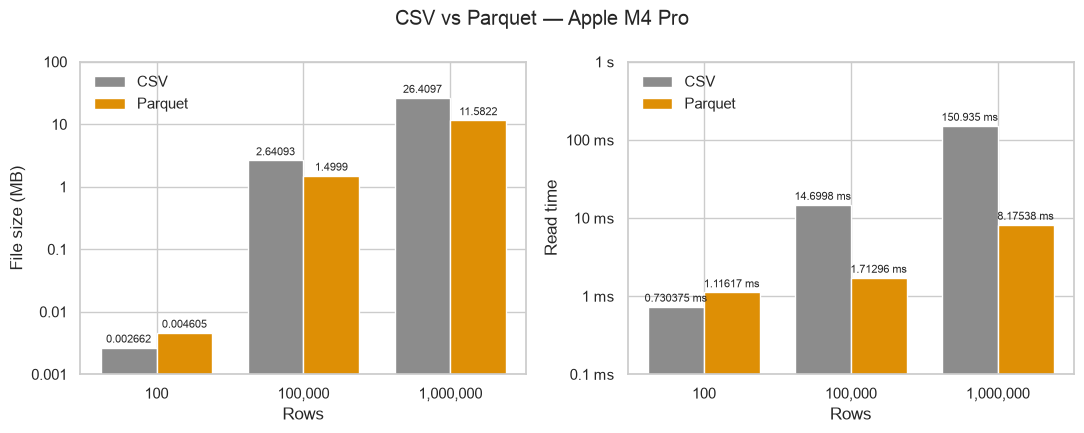

In [4]:
# Side-by-side bars: file size on the left, read time on the right.
# Log scale so 100 rows and 1 million fit together. The number on each bar is
# the measured value — bar height is not "how many times bigger".
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
positions = np.arange(len(formats))
width = 0.38
panels = [
    ("csv_mb", "parquet_mb", "File size (MB)", [0.001, 0.01, 0.1, 1, 10, 100], PLAIN),
    ("csv_read_s", "parquet_read_s", "Read time", [0.0001, 0.001, 0.01, 0.1, 1], SECONDS),
]
for axis, (csv_column, parquet_column, label, ticks, formatter) in zip(axes, panels):
    csv_bars = axis.bar(
        positions - width / 2, formats[csv_column], width, label="CSV", color="0.55"
    )
    parquet_bars = axis.bar(
        positions + width / 2,
        formats[parquet_column],
        width,
        label="Parquet",
        color=COLORS["Polars Eager"],
    )
    axis.set(ylabel=label, xlabel="Rows")
    log_y(axis, ticks, formatter)
    axis.set_ylim(ticks[0], ticks[-1])
    for bars, column in ((csv_bars, csv_column), (parquet_bars, parquet_column)):
        axis.bar_label(
            bars,
            labels=[formatter(value, None) for value in formats[column]],
            padding=2,
            fontsize=8,
        )
    axis.set_xticks(positions, [f"{rows:,}" for rows in formats["rows"]])
    axis.legend(frameon=False)
fig.suptitle(f"CSV vs Parquet — {MACHINE.split(',')[0]}")
fig.tight_layout()
plt.show()


## 3. Why Parquet

Parquet stores data **by column instead of by row**, in binary, with the schema written into the file. That buys you three things:

- values in a column sit together, so they compress well and scan quickly;
- every column carries its declared type, so nothing is guessed on read;
- a reader can load only the columns your query needs and skip the rest.

Two things to notice. First, look back at the 100-row line in the table: Parquet is *larger* than CSV there, because its schema and metadata cost more than the data itself — the advantage only appears once a file is big enough to be worth calling a dataset. Second, run the cell below: the source stores `rating` as a 32-bit float, but a CSV round-trip guesses 64-bit, doubling the memory for no extra information.

In [5]:
# dtypes = the stored type of each column (int32, float32, ...).
# CSV has no types, so pandas has to guess. Look at `rating`: float32 vs float64.
parquet_types = pd.read_parquet(FORMAT_DIR / "ratings_100k.parquet").dtypes
csv_types = pd.read_csv(FORMAT_DIR / "ratings_100k.csv").dtypes

display(pd.DataFrame({"parquet": parquet_types, "csv_round_trip": csv_types}))

,parquet,csv_round_trip
userId,int32,int64
movieId,int32,int64
rating,float32,float64
timestamp,int64,int64


## 4. A minimal cleaning workflow

Real input is rarely ready to use. The cell below deliberately damages a clean dataset — adding duplicate rows and blanking some ratings — then repairs it in three lines: **deduplicate, impute, normalize**. Watch the before and after counts.

Three steps is a starting point, not a checklist. In practice you would also validate schemas and value ranges, cast types, handle outliers and time zones, standardize categories, and reconcile joins against reference data. What would *you* add for a dataset you have worked with?

In [6]:
def report(label, frame):
    """Print how many rows, exact-duplicate rows, and blank ratings we have."""
    duplicates = frame.duplicated().sum()
    missing = frame["rating"].isna().sum()  # isna() means "is this cell empty?"
    print(
        f"{label}: {len(frame):,} rows, {duplicates:,} duplicates, {missing:,} missing"
    )


# The prepared file is already clean, so we add two common problems to fix.
dirty = source.head(200_000).copy()
# Blank 20,000 ratings. nan = "not a number" (empty).
dirty.loc[dirty.sample(20_000, random_state=0).index, "rating"] = float("nan")
# Paste the first 10,000 rows onto the end so some rows now appear twice.
dirty = pd.concat([dirty, dirty.head(10_000)], ignore_index=True)
report("before", dirty)

median_rating = dirty["rating"].median()  # middle remaining rating

# Three-line repair:
clean = dirty.drop_duplicates()  # 1. drop duplicate events
clean["rating"] = clean["rating"].fillna(median_rating)  # 2. fill blanks
clean["rating_scaled"] = (clean["rating"] - 0.5) / 4.5  # 3. stretch 0.5–5 onto 0–1

report("after ", clean)
display(clean.head(3))

before: 210,000 rows, 10,000 duplicates, 21,015 missing
after : 200,000 rows, 0 duplicates, 0 missing


,userId,movieId,rating,timestamp,rating_scaled
0,163692,201749,4.0,1601327701,0.777778
1,63885,914,3.0,851349682,0.555556
2,197767,593,3.5,1546504318,0.666667


## 5. One task, three engines

Every engine below runs **exactly the same task** on the same 1M-row Parquet file:

> read `movieId` and `rating` → group by movie → average rating and rating count → keep movies with at least 1,000 ratings → join the titles → sort by rating.

Each engine gets one function, written once here and reused in section 6, so the timings later compare identical work. As you read the next few cells, look for two differences and ignore everything else.

**Difference 1 — syntax.** The same operation is spelled differently in each API:

| Operation | Pandas | Polars | PySpark |
|---|---|---|---|
| Read | `read_parquet` | `read_parquet` / `scan_parquet` | `read.parquet` |
| Group | `groupby` | `group_by` | `groupBy` |
| Aggregate | `agg(name=(col, "mean"))` | `agg(pl.col(col).mean())` | `agg(F.avg(col))` |
| Filter rows | `query` / boolean mask | `filter` | `filter` / `where` |
| Sort | `sort_values` | `sort` | `orderBy` |
| Run it | immediately | immediately, or on `collect()` | on an action such as `toPandas()` |

**Difference 2 — execution time.** You will measure that in section 6.

In [7]:
def run_pandas(path):
    """Same query as the other engines: group, count, keep popular movies, join titles."""
    ratings = pd.read_parquet(path, columns=["movieId", "rating"])
    movies = pd.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
    return (
        ratings.groupby("movieId")  # one bucket per movie
        .agg(
            avg_rating=("rating", "mean"),  # average stars
            rating_count=("rating", "count"),  # how many people rated it
        )
        .query("rating_count >= @MIN_RATINGS")  # keep widely rated movies
        .reset_index()
        .merge(movies, on="movieId")  # add the title (join on movieId)
        .sort_values(["avg_rating", "movieId"], ascending=[False, True])
    )


pandas_top = run_pandas(RATINGS_PATH)
display(pandas_top.head(TOP_N)[["title", "avg_rating", "rating_count"]])

,title,avg_rating,rating_count
17,"Shawshank Redemption, The (1994)",4.375311,3212
44,"Godfather, The (1972)",4.310750,2000
59,"Godfather: Part II, The (1974)",4.268394,1332
27,Schindler's List (1993),4.266581,2337
5,"Usual Suspects, The (1995)",4.242021,2068
102,Spirited Away (Sen to Chihiro no kamikakushi) ...,4.230067,1041
50,One Flew Over the Cuckoo's Nest (1975),4.222101,1371
41,Dr. Strangelove or: How I Learned to Stop Worr...,4.210318,1008
81,Fight Club (1999),4.199122,2393
15,Pulp Fiction (1994),4.197892,2989


In [8]:
def run_polars_eager(path):
    """Same steps as Pandas. Note group_by (with an underscore) instead of groupby."""
    ratings = pl.read_parquet(path, columns=["movieId", "rating"])  # loads the file now
    movies = pl.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
    return (
        ratings.group_by("movieId")
        .agg(
            pl.col("rating").mean().alias("avg_rating"),  # rename the column
            pl.len().alias("rating_count"),  # how many ratings this movie got
        )
        .filter(pl.col("rating_count") >= MIN_RATINGS)  # same idea as Pandas .query
        .join(movies, on="movieId")  # same idea as Pandas .merge
        .sort(["avg_rating", "movieId"], descending=[True, False])
    )


polars_eager_top = run_polars_eager(RATINGS_PATH)
display(polars_eager_top.head(TOP_N).select("title", "avg_rating", "rating_count"))

title,avg_rating,rating_count
str,f32,u32
"""Shawshank Redemption, The (199…",4.375311,3212
"""Godfather, The (1972)""",4.31075,2000
"""Godfather: Part II, The (1974)""",4.268394,1332
"""Schindler's List (1993)""",4.266581,2337
"""Usual Suspects, The (1995)""",4.242021,2068
"""Spirited Away (Sen to Chihiro …",4.230067,1041
"""One Flew Over the Cuckoo's Nes…",4.222101,1371
"""Dr. Strangelove or: How I Lear…",4.210318,1008
"""Fight Club (1999)""",4.199122,2393


### Polars has a second mode: lazy

`read_parquet` loads the file the moment you call it. `scan_parquet` reads **nothing** — it records what you asked for and builds a plan. Only `collect()` runs it.

Giving the engine your whole pipeline up front lets it optimize before touching data. In the plan printed below, find the line `PROJECT 2/8 COLUMNS`: Polars worked out by itself that only two of the file's eight columns are needed. The eager version above skipped those six too, but only because you told it `columns=["movieId", "rating"]` by hand.

Keep this in mind for the next cell — PySpark works the same way: describe the work, then trigger it.

In [9]:
def polars_lazy_plan(path):
    """Describe the query. scan_parquet does NOT read the file yet."""
    ratings = pl.scan_parquet(path)
    movies = pl.scan_parquet(MOVIES_PATH).select("movieId", "title")
    return (
        ratings.group_by("movieId")
        .agg(
            pl.col("rating").mean().alias("avg_rating"),
            pl.len().alias("rating_count"),
        )
        .filter(pl.col("rating_count") >= MIN_RATINGS)
        .join(movies, on="movieId")
        .sort(["avg_rating", "movieId"], descending=[True, False])
    )


def run_polars_lazy(path):
    # collect() is the moment the file is actually read and the query runs.
    return polars_lazy_plan(path).collect()


# explain() prints the plan. Look for PROJECT 2/8 COLUMNS — only 2 of 8 columns are needed.
plan = polars_lazy_plan(RATINGS_PATH).explain()
print(plan.replace(f"{ROOT}/", ""))

polars_lazy_top = run_polars_lazy(RATINGS_PATH)

SORT BY [descending: [true, false]] [col("avg_rating"), col("movieId")]
  INNER JOIN:
  LEFT PLAN ON: [col("movieId")]
    FILTER col("rating_count") >= 1000
    FROM
      AGGREGATE[maintain_order: false]
        [col("rating").mean().alias("avg_rating"), len().alias("rating_count")] BY [col("movieId")]
        FROM
        Parquet SCAN [data/parquet/ratings_1m.parquet]
        PROJECT 2/8 COLUMNS
        ESTIMATED ROWS: 1000000
  RIGHT PLAN ON: [col("movieId")]
    Parquet SCAN [data/parquet/movies.parquet]
    PROJECT 2/3 COLUMNS
    ESTIMATED ROWS: 87585
  END INNER JOIN


In [10]:
spark = spark_top = None
if JAVA_READY:
    from pyspark.sql import SparkSession, functions as F

    # Starting Spark takes a few seconds even before any data is read. That is the "fixed cost".
    session_start = time.perf_counter()
    spark = (
        SparkSession.builder.master("local[*]")  # use every CPU core on this laptop
        .appName("dataframe engines demo")
        .config("spark.ui.enabled", "false")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.ui.showConsoleProgress", "false")
        .config("spark.log.level", "ERROR")
        .getOrCreate()
    )
    print(f"Spark session ready in {time.perf_counter() - session_start:.1f} s")


def run_spark(path):
    """Same query again. groupBy / orderBy / toPandas are Spark's spellings."""
    ratings = spark.read.parquet(str(path)).select("movieId", "rating")
    movies = spark.read.parquet(str(MOVIES_PATH)).select("movieId", "title")
    return (
        ratings.groupBy("movieId")
        .agg(
            F.avg("rating").alias("avg_rating"),
            F.count("rating").alias("rating_count"),
        )
        .filter(F.col("rating_count") >= MIN_RATINGS)
        .join(movies, "movieId")
        .orderBy(F.desc("avg_rating"), F.asc("movieId"))
        .toPandas()  # this is the "action" that actually runs the query
    )


if spark is not None:
    spark_top = run_spark(RATINGS_PATH)
    display(spark_top.head(TOP_N)[["title", "avg_rating", "rating_count"]])
else:
    print("Java 17 not found — skipping PySpark.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/01 17:28:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting Spark log level to "ERROR".


Spark session ready in 2.5 s


,title,avg_rating,rating_count
0,"Shawshank Redemption, The (1994)",4.375311,3212
1,"Godfather, The (1972)",4.310750,2000
2,"Godfather: Part II, The (1974)",4.268393,1332
3,Schindler's List (1993),4.266581,2337
4,"Usual Suspects, The (1995)",4.242021,2068
5,Spirited Away (Sen to Chihiro no kamikakushi) ...,4.230067,1041
6,One Flew Over the Cuckoo's Nest (1975),4.222101,1371
7,Dr. Strangelove or: How I Learned to Stop Worr...,4.210317,1008
8,Fight Club (1999),4.199122,2393
9,Pulp Fiction (1994),4.197892,2989


In [11]:
def comparable(frame):
    """Put every engine's result in the same shape so we can compare them."""
    frame = frame.to_pandas() if isinstance(frame, pl.DataFrame) else frame
    return (
        frame[["movieId", "avg_rating", "rating_count"]]
        .astype({"avg_rating": "float64", "rating_count": "int64"})
        .sort_values("movieId")
        .reset_index(drop=True)
    )


answers = {
    "Polars Eager": polars_eager_top,
    "Polars Lazy": polars_lazy_top,
    "PySpark": spark_top,
}
reference = comparable(pandas_top)
print(f"Pandas found {len(reference):,} movies with at least {MIN_RATINGS:,} ratings.")
for engine, answer in answers.items():
    if answer is None:
        continue
    # assert_frame_equal raises an error if the tables differ — silence means they match.
    pd.testing.assert_frame_equal(reference, comparable(answer), atol=1e-4)
    print(f"{engine}: identical to the Pandas answer")

Pandas found 126 movies with at least 1,000 ratings.
Polars Eager: identical to the Pandas answer
Polars Lazy: identical to the Pandas answer
PySpark: identical to the Pandas answer


## 6. The same task as the data grows

Now call those same four functions on five row counts, from 100 up to 32 million. The timing covers reading the file and materializing the answer, since that is what you actually wait for.

Why time it here instead of in section 5? A first call measures warm-up as much as the query — Spark compiles the plan, Polars starts its thread pool. Every engine has run once by now, so these are steady-state numbers. Spark's session startup, printed earlier, is paid once on top.

Your numbers will not match the ones saved here, which is why the machine is printed under the chart. The *shape* of the lines is the lesson, not the values.

In [12]:
# Files of growing size. We reuse the four functions defined in section 5.
SCALE_PATHS = {
    100: PARQUET_DIR / "ratings_100.parquet",
    200_000: PARQUET_DIR / "ratings_200k.parquet",
    1_000_000: PARQUET_DIR / "ratings_1m.parquet",
    10_000_000: PARQUET_DIR / "ratings_10m.parquet",
    32_000_204: PARQUET_DIR / "ratings_32m.parquet",
}

runners = {
    "Pandas": run_pandas,
    "Polars Eager": run_polars_eager,
    "Polars Lazy": run_polars_lazy,
}
if spark is not None:
    runners["PySpark"] = run_spark

timings = []
for rows, path in SCALE_PATHS.items():
    if not path.exists():
        continue
    for engine, run in runners.items():
        start = time.perf_counter()
        run(path)  # same query, bigger file
        timings.append(
            {"engine": engine, "rows": rows, "seconds": time.perf_counter() - start}
        )

scaling = pd.DataFrame(timings)
# pivot = one column per engine, one row per file size
display(
    scaling.pivot(index="rows", columns="engine", values="seconds").style.format(
        "{:.3f} s"
    )
)

engine,Pandas,Polars Eager,Polars Lazy,PySpark
rows,,,,
100,0.011 s,0.007 s,0.004 s,0.185 s
200000,0.013 s,0.008 s,0.005 s,0.246 s
1000000,0.022 s,0.014 s,0.007 s,0.288 s
10000000,0.158 s,0.063 s,0.044 s,0.482 s
32000204,0.463 s,0.236 s,0.128 s,0.656 s


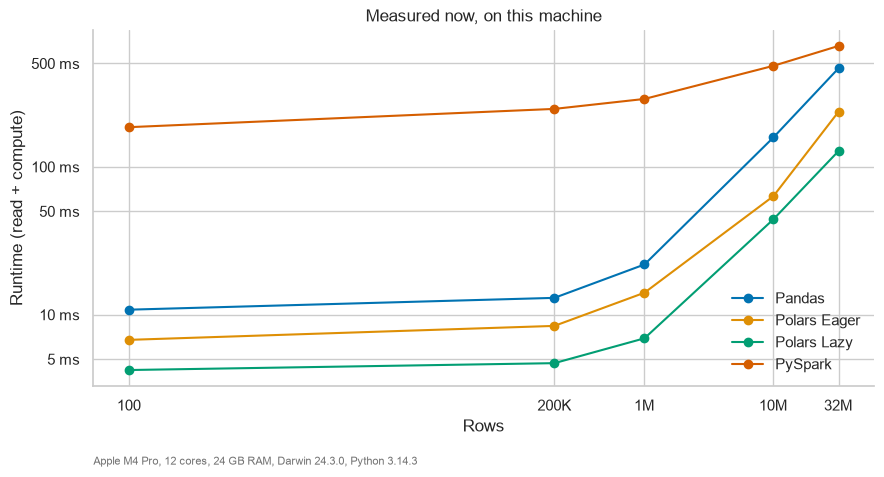

In [13]:
# One line per engine. Both axes are log scale so 100 rows and 32 million fit on one chart.
fig, ax = plt.subplots(figsize=(9, 5))
for engine in ENGINES:
    group = scaling[scaling["engine"] == engine]
    if group.empty:
        continue
    ax.plot(
        group["rows"], group["seconds"], marker="o", label=engine, color=COLORS[engine]
    )
ax.set(
    xscale="log",
    xlabel="Rows",
    ylabel="Runtime (read + compute)",
    title="Measured now, on this machine",
)
log_y(ax, [0.005, 0.01, 0.05, 0.1, 0.5])
ax.set_xticks(list(SCALE_PATHS), ["100", "200K", "1M", "10M", "32M"])
ax.legend(frameon=False)
ax.text(0, -0.22, MACHINE, transform=ax.transAxes, fontsize=8, color="0.45")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### Out to one billion rows

Five sizes fit in a class, but they never give PySpark a chance to look good. To find the point where it takes over, the data has to grow past what one laptop holds comfortably.

These numbers were measured ahead of time: the identical query, three runs per size, median reported, on the machine named under the chart. Lines stop where an engine was not run — Pandas past 100M and Polars Eager past 350M need more memory than is sensible here, while Polars Lazy and PySpark continue to a billion rows.

One difference from the chart above: each prepared run starts and stops its own Spark session, so Spark's fixed cost is included at every point. That is why its small-data line sits higher here, and it is the more honest number when you are deciding whether to reach for Spark at all.

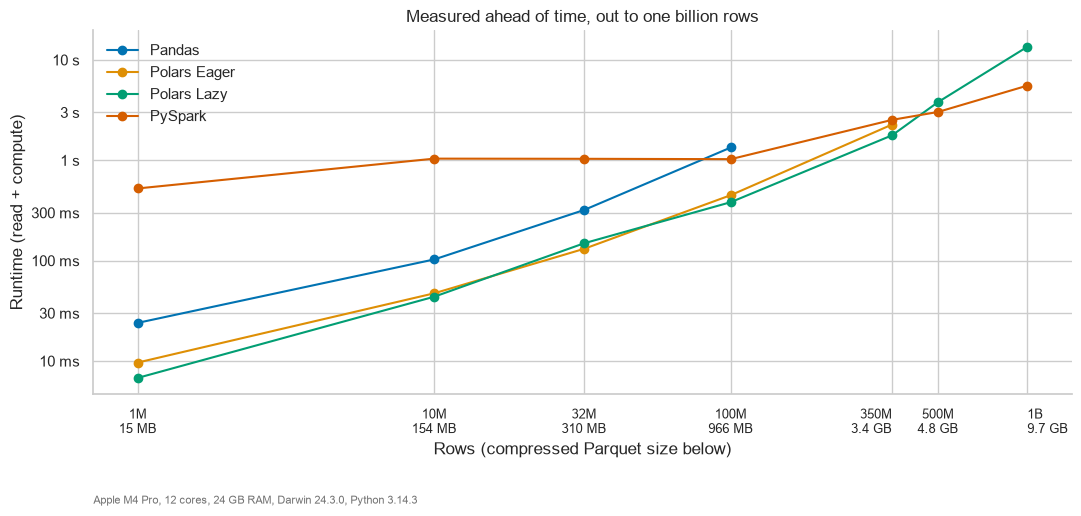

In [14]:
# Prepared timings go out to 1 billion rows. Students usually do not have these files.
BIG_SIZES = {
    1_000_000: ("1M", PARQUET_DIR / "ratings_1m.parquet"),
    10_000_000: ("10M", PARQUET_DIR / "ratings_10m.parquet"),
    32_000_204: ("32M", PARQUET_DIR / "ratings_32m.parquet"),
    100_000_000: ("100M", SYNTHETIC_DIR / "ratings_100m.parquet"),
    350_000_000: ("350M", SYNTHETIC_DIR / "ratings_350m.parquet"),
    500_000_000: ("500M", SYNTHETIC_DIR / "ratings_500m.parquet"),
    1_000_000_000: ("1B", SYNTHETIC_DIR / "ratings_1b.parquet"),
}

# Read the pre-measured numbers. We are NOT re-running 1 billion rows in class.
prepared = pd.read_csv(ROOT / "results/benchmark_results_simple.csv")
prepared = prepared[prepared["rows"].isin(BIG_SIZES)].sort_values("rows")


def size_on_disk(path):
    """Compressed Parquet size, or a note when the file was never created locally."""
    files = [path] if path.is_file() else sorted(path.glob("*.parquet"))
    if not files:
        return "not local"
    total = sum(file.stat().st_size for file in files)
    return f"{total / 1e9:.1f} GB" if total >= 1e9 else f"{total / 1e6:.0f} MB"


tick_positions = list(BIG_SIZES)
tick_labels = [f"{name}\n{size_on_disk(path)}" for name, path in BIG_SIZES.values()]

fig, ax = plt.subplots(figsize=(11, 5.5))
for engine in ENGINES:
    group = prepared[prepared["framework"] == engine]
    ax.plot(
        group["rows"],
        group["runtime_seconds"],
        marker="o",
        label=engine,
        color=COLORS[engine],
    )
ax.set(
    xscale="log",
    xlabel="Rows (compressed Parquet size below)",
    ylabel="Runtime (read + compute)",
    title="Measured ahead of time, out to one billion rows",
)
log_y(ax, [0.01, 0.03, 0.1, 0.3, 1, 3, 10])
ax.set_xticks(tick_positions, tick_labels)
ax.tick_params(axis="x", labelsize=9)
# The last three sizes sit close together on a log axis; nudge them apart.
drawn = ax.get_xticklabels()
drawn[-3].set_horizontalalignment("right")
drawn[-1].set_horizontalalignment("left")
ax.legend(frameon=False)
ax.text(0, -0.3, MACHINE, transform=ax.transAxes, fontsize=8, color="0.45")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### Reading the chart

- **Below about 100M rows you are looking at overhead, not data.** Spark barely moves off 0.5–1 s while the data grows a hundredfold, because that time is planning and scheduling; Polars is roughly **75x faster at 1M rows** by not paying for coordination it does not need.
- **The lines converge between 100M and 500M.** Spark passes Pandas between 32M and 100M, and passes Polars Lazy between 350M and 500M — Spark did not get faster, the others grew up to meet its fixed cost.
- **Past 500M they separate again, the other way.** Doubling to 1B costs Spark **1.8x** (3.03 to 5.54 s) but costs Polars Lazy **3.6x** (3.80 to 13.49 s): Polars is running out of machine while Spark simply adds partitions.
- **Eager and lazy stay close**, within about 5% at 350M (2.27 s vs 2.16 s), because this query is simple enough that column pruning is the only optimization available.
- **Two caveats.** Spark runs locally on one laptop here, so this shows its execution model rather than a cluster, and every line ends where that engine hit a sensible memory limit.

## 7. What to take away

| Engine | Fits when |
|---|---|
| **Pandas** | The data fits comfortably in memory and you want the largest library ecosystem. |
| **Polars Eager** | Same single machine, but you want multiple cores used well — several times faster than Pandas on the same file. |
| **Polars Lazy** | You can describe the whole pipeline before running it and let the optimizer prune columns and reorder work. Same speed advantage, less hand-tuning. |
| **PySpark** | The data is too large for one machine. Startup and coordination cost a fixed amount of time up front, which is why Spark looks absurd on small files. |

**In one sentence:** Spark's overhead is only worth paying once your data stops fitting on one machine — on this hardware, somewhere past 500 million rows.

There is no universal winner. Before you choose, ask how much data you actually have, what hardware you can run it on, and when the answer is due.

In [15]:
# Shut Spark down so it is not still using memory after the notebook finishes.
if spark is not None:
    spark.stop()

In [16]:
# l1 = [1, 2, 2, 3, 4, 5]

# for item in l1:
#     if item == 2:
#         l1.remove(item)
    
# print(l1)